
# 03 - Regularization

## Decisiones tomadas




In [2]:
print("done")

done


In [3]:

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from torch.utils.tensorboard import SummaryWriter

print("Imports OK")


Imports OK


In [4]:

class SkinDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.image_paths = []
        self.labels = []

        self.class_names = sorted(os.listdir(root_dir))

        self.class_to_idx = {
            cls_name: idx
            for idx, cls_name in enumerate(self.class_names)
        }

        for class_name in self.class_names:

            class_dir = os.path.join(root_dir, class_name)

            if not os.path.isdir(class_dir):
                continue

            for fname in os.listdir(class_dir):

                if fname.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp", ".webp")
                ):

                    self.image_paths.append(
                        os.path.join(class_dir, fname)
                    )

                    self.labels.append(
                        self.class_to_idx[class_name]
                    )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]

        image = Image.open(image_path).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


print("Dataset class OK")


Dataset class OK


In [5]:

train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

print("Transforms OK")


Transforms OK


In [6]:

train_dir = "data/Split_smol/train"
val_dir = "data/Split_smol/val"

train_dataset = SkinDataset(
    train_dir,
    train_transform
)

val_dataset = SkinDataset(
    val_dir,
    val_transform
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

print("Classes:")
print(train_dataset.class_names)


Train images: 664
Validation images: 181
Classes:
['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']


In [11]:
class BaselineCNN(nn.Module):

    def __init__(self, num_classes):

        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Opcional: Dropout sobre mapas de características
            nn.Dropout2d(0.25)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 16 * 16,
                256
            ),

            nn.ReLU(),

            # Dropout clásico
            nn.Dropout(0.2),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

num_classes = len(train_dataset.class_names)

model = BaselineCNN(num_classes)

model = model.to(device)

print(model)


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=2

In [12]:

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

writer = SummaryWriter("runs/regularization_cnn")

n_epochs = 20

best_accuracy = 0.0

for epoch in range(n_epochs):

    model.train()

    running_loss = 0.0

    progress_bar = tqdm(train_loader)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_description(
            f"Epoch {epoch+1}/{n_epochs} - Loss: {loss.item():.4f}"
        )

    epoch_loss = running_loss / len(train_loader)

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = correct / total

    writer.add_scalar(
        "Loss/train",
        epoch_loss,
        epoch
    )

    writer.add_scalar(
        "Accuracy/validation",
        accuracy,
        epoch
    )

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={epoch_loss:.4f} | "
        f"Validation Accuracy={accuracy:.4f}"
    )

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        torch.save(
            model.state_dict(),
            "regularization_cnn_best.pth"
        )

        print("Nuevo mejor modelo guardado")

print("\nEntrenamiento finalizado")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")


Epoch 1/20 - Loss: 2.3097: 100%|██████████| 21/21 [00:13<00:00,  1.53it/s]


Epoch 1: Train Loss=5.1571 | Validation Accuracy=0.1602
Nuevo mejor modelo guardado


Epoch 2/20 - Loss: 1.5006: 100%|██████████| 21/21 [00:13<00:00,  1.58it/s]


Epoch 2: Train Loss=1.8139 | Validation Accuracy=0.3425
Nuevo mejor modelo guardado


Epoch 3/20 - Loss: 1.7742: 100%|██████████| 21/21 [00:13<00:00,  1.54it/s]


...

Epoch 18: Train Loss=1.0695 | Validation Accuracy=0.5359


Epoch 19/20 - Loss: 0.6887: 100%|██████████| 21/21 [00:11<00:00,  1.80it/s]


Epoch 19: Train Loss=1.1051 | Validation Accuracy=0.5083


Epoch 20/20 - Loss: 1.1876: 100%|██████████| 21/21 [00:11<00:00,  1.87it/s]


Epoch 20: Train Loss=1.0510 | Validation Accuracy=0.5249

Entrenamiento finalizado
Best Validation Accuracy: 0.5635


                            precision    recall  f1-score   support

         Actinic keratosis       0.18      0.15      0.16        20
         Atopic Dermatitis       0.65      0.81      0.72        21
          Benign keratosis       1.00      0.95      0.97        20
            Dermatofibroma       0.29      0.50      0.36        20
         Melanocytic nevus       0.67      0.80      0.73        20
                  Melanoma       0.52      0.55      0.54        20
   Squamous cell carcinoma       0.40      0.30      0.34        20
Tinea Ringworm Candidiasis       0.57      0.20      0.30        20
           Vascular lesion       0.94      0.80      0.86        20

                  accuracy                           0.56       181
                 macro avg       0.58      0.56      0.55       181
              weighted avg       0.58      0.56      0.56       181



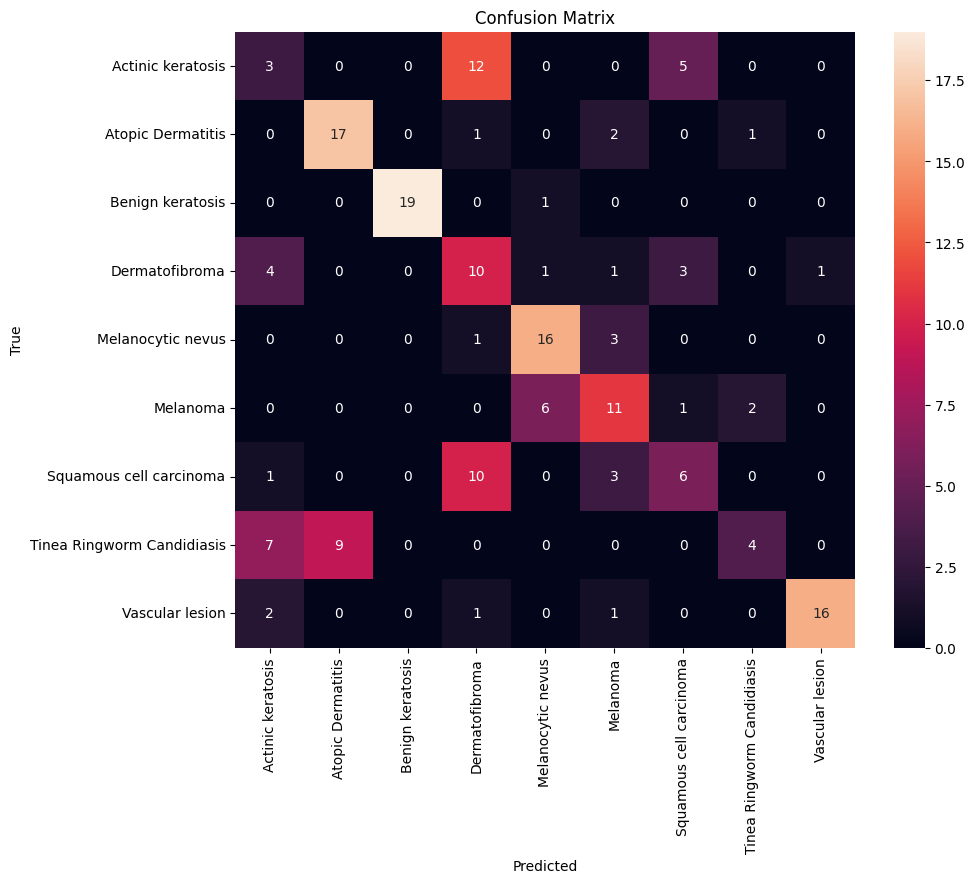

In [13]:

model.load_state_dict(
    torch.load("regularization_cnn_best.pth")
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.class_names
    )
)

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.class_names,
    yticklabels=train_dataset.class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()



## TensorBoard

Para visualizar métricas de entrenamiento:

```bash
tensorboard --logdir=runs
```

Luego abrir:

```text
http://localhost:6006
```


In [14]:

# Opcional:
# Ejecutar TensorBoard dentro del notebook

# %load_ext tensorboard
# %tensorboard --logdir runs



# Conclusiones

